# Experiment 5 - Color HSV + GLCM

**Pipeline preprocessing:** Baseline (grayscale + resize untuk GLCM) ditambah ekstraksi fitur statistik warna HSV langsung dari gambar warna asli.

## Setup

In [1]:
import sys
import os

if 'google.colab' in sys.modules:
    print("Berjalan di Google Colab. Menyiapkan environment...")
    from google.colab import drive
    drive.mount('/content/drive')
    
    REPO_DIR = '/content/cloud-classification'
    if not os.path.exists(REPO_DIR):
        !git clone https://github.com/Vuxyn/cloud-classification.git
    else:
        !git -C {REPO_DIR} pull
        
    %cd {REPO_DIR}/notebooks
    
    ZIP_PATH = '/content/drive/MyDrive/GCD-zip.zip'
    EXTRACT_DIR = '/content/GCD-zip'
    
    if os.path.exists(ZIP_PATH):
        if not os.path.exists(EXTRACT_DIR):
            print(f"Mengekstrak {ZIP_PATH} ke {EXTRACT_DIR}...")
            import zipfile
            with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
                zip_ref.extractall(EXTRACT_DIR)
            print("Ekstraksi selesai!")
        else:
            print(f"Dataset sudah diekstrak di {EXTRACT_DIR}")
    else:
        print(f"Peringatan: File zip {ZIP_PATH} tidak ditemukan di Google Drive Anda.")
        print("Pastikan nama file zip di Drive utama adalah 'GCD-zip.zip'.")

    # Cek apakah runtime menggunakan GPU
    import subprocess
    try:
        subprocess.check_output('nvidia-smi')
        print("GPU NVIDIA terdeteksi, menginstall cupy...")
        !pip install cupy-cuda12x python-dotenv gdown
    except Exception:
        print("GPU tidak aktif. Menjalankan menggunakan CPU.")
        !pip install python-dotenv gdown

In [2]:
import sys
sys.path.append('..')  # supaya src/ bisa diimport dari notebooks/

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from src.loader import get_dataset_root, load_dataset
from src.image_processing import *

EXPERIMENT_NAME = "experiment5"


CuPy tidak tersedia - fallback ke NumPy (CPU)


## Data Loading

In [3]:
DATASET_ROOT = get_dataset_root()
# Muat gambar warna asli (color=True) untuk ekstraksi fitur warna HSV
images, labels, filenames = load_dataset(DATASET_ROOT, target_size=(128, 128), color=True)
print(f"Dataset loaded: {len(images)} gambar warna, {len(set(labels))} kelas")

Environment: Lokal
DATASET_ROOT dari .env: D:\INFORMATICS\SEMESTER 4\IMAGE PROCESSING\Praktikum\Project\GCD


Loading cumulus:   0%|          | 0/775 [00:00<?, ?it/s]

Loading cumulus:   1%|▏         | 11/775 [00:00<00:07, 106.69it/s]

Loading cumulus:   3%|▎         | 26/775 [00:00<00:05, 130.06it/s]

Loading cumulus:   5%|▌         | 41/775 [00:00<00:05, 137.30it/s]

...

Loading mixed:  91%|█████████▏| 555/607 [00:03<00:00, 130.35it/s]

Loading mixed:  94%|█████████▎| 569/607 [00:04<00:00, 129.60it/s]

Loading mixed:  96%|█████████▌| 583/607 [00:04<00:00, 124.92it/s]

Loading mixed:  99%|█████████▉| 600/607 [00:04<00:00, 136.01it/s]

Dataset loaded: 19000 gambar, 7 kelas, ukuran=(128, 128)
Dataset loaded: 19000 gambar warna, 7 kelas


## Feature Extraction - Color HSV

In [4]:
h_means, h_stds = [], []
s_means, s_stds = [], []
v_means, v_stds = [], []

for img in tqdm(images, desc="Extracting HSV features"):
    # img dimuat dalam format BGR oleh OpenCV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    h_means.append(np.mean(hsv[:, :, 0]))
    h_stds.append(np.std(hsv[:, :, 0]))
    
    s_means.append(np.mean(hsv[:, :, 1]))
    s_stds.append(np.std(hsv[:, :, 1]))
    
    v_means.append(np.mean(hsv[:, :, 2]))
    v_stds.append(np.std(hsv[:, :, 2]))

Extracting HSV features:   0%|          | 0/19000 [00:00<?, ?it/s]

Extracting HSV features:   1%|          | 149/19000 [00:00<00:12, 1488.43it/s]

Extracting HSV features:   2%|▏         | 359/19000 [00:00<00:10, 1846.82it/s]

Extracting HSV features:   3%|▎         | 595/19000 [00:00<00:08, 2078.41it/s]

Extracting HSV features:   5%|▍         | 861/19000 [00:00<00:07, 2303.47it/s]

...

Extracting HSV features:  96%|█████████▋| 18314/19000 [00:07<00:00, 2121.24it/s]

Extracting HSV features:  98%|█████████▊| 18533/19000 [00:07<00:00, 1928.18it/s]

Extracting HSV features:  99%|█████████▊| 18741/19000 [00:07<00:00, 1965.89it/s]

Extracting HSV features: 100%|█████████▉| 18991/19000 [00:07<00:00, 2108.30it/s]

Extracting HSV features: 100%|██████████| 19000/19000 [00:07<00:00, 2376.48it/s]

## Preprocessing for GLCM (Convert to Grayscale)

In [5]:
# Ubah gambar warna ke grayscale untuk ekstraksi GLCM tekstur
images_preprocessed = np.array([
    cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) for img in tqdm(images, desc="Converting to grayscale")
])

Converting to grayscale:   0%|          | 0/19000 [00:00<?, ?it/s]

Converting to grayscale:  20%|██        | 3886/19000 [00:00<00:00, 38849.66it/s]

Converting to grayscale:  43%|████▎     | 8135/19000 [00:00<00:00, 40977.09it/s]

Converting to grayscale:  64%|██████▍   | 12233/19000 [00:00<00:00, 39979.23it/s]

Converting to grayscale:  85%|████████▌ | 16234/19000 [00:00<00:00, 38985.57it/s]

Converting to grayscale: 100%|██████████| 19000/19000 [00:00<00:00, 38488.89it/s]

## Feature Extraction - GLCM Texture

In [6]:
def glcm(image, angle):
    if angle == 0:
        angles = [0]
    elif angle == 45:
        angles = [np.pi / 4]
    elif angle == 90:
        angles = [np.pi / 2]
    elif angle == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Sudut tidak valid. Gunakan 0, 45, 90, atau 135.")

    return graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)


def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]


def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]


def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]


def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]


def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]


def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]


def entropyGlcm(matriks):
    return entropy(matriks.ravel())


In [7]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in tqdm(range(len(images_preprocessed)), desc="Extracting GLCM features"):
    g0 = glcm(images_preprocessed[i], 0)
    g45 = glcm(images_preprocessed[i], 45)
    g90 = glcm(images_preprocessed[i], 90)
    g135 = glcm(images_preprocessed[i], 135)
    
    Kontras0.append(contrast(g0))
    Kontras45.append(contrast(g45))
    Kontras90.append(contrast(g90))
    Kontras135.append(contrast(g135))
    
    dissimilarity0.append(dissimilarity(g0))
    dissimilarity45.append(dissimilarity(g45))
    dissimilarity90.append(dissimilarity(g90))
    dissimilarity135.append(dissimilarity(g135))
    
    homogenity0.append(homogenity(g0))
    homogenity45.append(homogenity(g45))
    homogenity90.append(homogenity(g90))
    homogenity135.append(homogenity(g135))
    
    entropy0.append(entropyGlcm(g0))
    entropy45.append(entropyGlcm(g45))
    entropy90.append(entropyGlcm(g90))
    entropy135.append(entropyGlcm(g135))
    
    ASM0.append(ASM(g0))
    ASM45.append(ASM(g45))
    ASM90.append(ASM(g90))
    ASM135.append(ASM(g135))
    
    energy0.append(energy(g0))
    energy45.append(energy(g45))
    energy90.append(energy(g90))
    energy135.append(energy(g135))
    
    correlation0.append(correlation(g0))
    correlation45.append(correlation(g45))
    correlation90.append(correlation(g90))
    correlation135.append(correlation(g135))

Extracting GLCM features:   0%|          | 0/19000 [00:00<?, ?it/s]

Extracting GLCM features:   0%|          | 2/19000 [00:00<19:21, 16.36it/s]

Extracting GLCM features:   0%|          | 6/19000 [00:00<11:33, 27.37it/s]

Extracting GLCM features:   0%|          | 10/19000 [00:00<10:05, 31.36it/s]

Extracting GLCM features:   0%|          | 14/19000 [00:00<09:27, 33.46it/s]

...

Extracting GLCM features: 100%|█████████▉| 18976/19000 [04:55<00:00, 63.30it/s]

Extracting GLCM features: 100%|█████████▉| 18983/19000 [04:55<00:00, 63.55it/s]

Extracting GLCM features: 100%|█████████▉| 18991/19000 [04:55<00:00, 65.53it/s]

Extracting GLCM features: 100%|█████████▉| 18998/19000 [04:55<00:00, 66.54it/s]

Extracting GLCM features: 100%|██████████| 19000/19000 [04:55<00:00, 64.28it/s]

In [8]:
dataTable = {
    'Filename': filenames,
    'Label': labels,
    # Fitur Tekstur GLCM
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
    # Fitur Warna HSV
    'HSV_H_Mean': h_means, 'HSV_H_Std': h_stds,
    'HSV_S_Mean': s_means, 'HSV_S_Std': s_stds,
    'HSV_V_Mean': v_means, 'HSV_V_Std': v_stds
}

df = pd.DataFrame(dataTable)
csv_path = f'hasil_ekstraksi_{EXPERIMENT_NAME}.csv'
df.to_csv(csv_path, index=False)
print(f'Fitur gabungan tersimpan ke {csv_path}')
df.head()

Fitur gabungan tersimpan ke hasil_ekstraksi_experiment5.csv


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,Correlation0,Correlation45,Correlation90,Correlation135,HSV_H_Mean,HSV_H_Std,HSV_S_Mean,HSV_S_Std,HSV_V_Mean,HSV_V_Std
0,1_cumulus_000001.jpg,cumulus,10.996186,16.987166,14.126784,25.286379,0.493997,0.417731,0.460576,0.395001,...,0.992928,0.989076,0.990915,0.983738,106.120728,0.859418,121.359314,26.700299,213.155884,20.555847
1,1_cumulus_000002.jpg,cumulus,8.735113,17.258913,13.949188,23.800794,0.530764,0.420436,0.486924,0.421011,...,0.997524,0.995109,0.996040,0.993256,104.216370,1.918982,145.239624,57.940921,235.902893,15.112288
2,1_cumulus_000003.jpg,cumulus,28.462475,58.286875,33.453433,52.231880,0.410892,0.345354,0.407398,0.334297,...,0.992371,0.984310,0.990991,0.985937,104.395874,1.978219,169.983215,53.948774,218.482910,25.071316
3,1_cumulus_000004.jpg,cumulus,17.964813,34.591605,21.262057,35.216256,0.495777,0.409538,0.466190,0.395727,...,0.995454,0.991230,0.994612,0.991071,104.537048,1.625028,163.944946,57.497891,219.584900,23.792035
4,1_cumulus_000005.jpg,cumulus,10.477977,28.578833,22.140440,30.990762,0.528796,0.351345,0.401584,0.366098,...,0.997068,0.991998,0.993812,0.991322,105.445496,1.864478,107.526978,45.877355,224.429321,26.750860


## Feature Selection

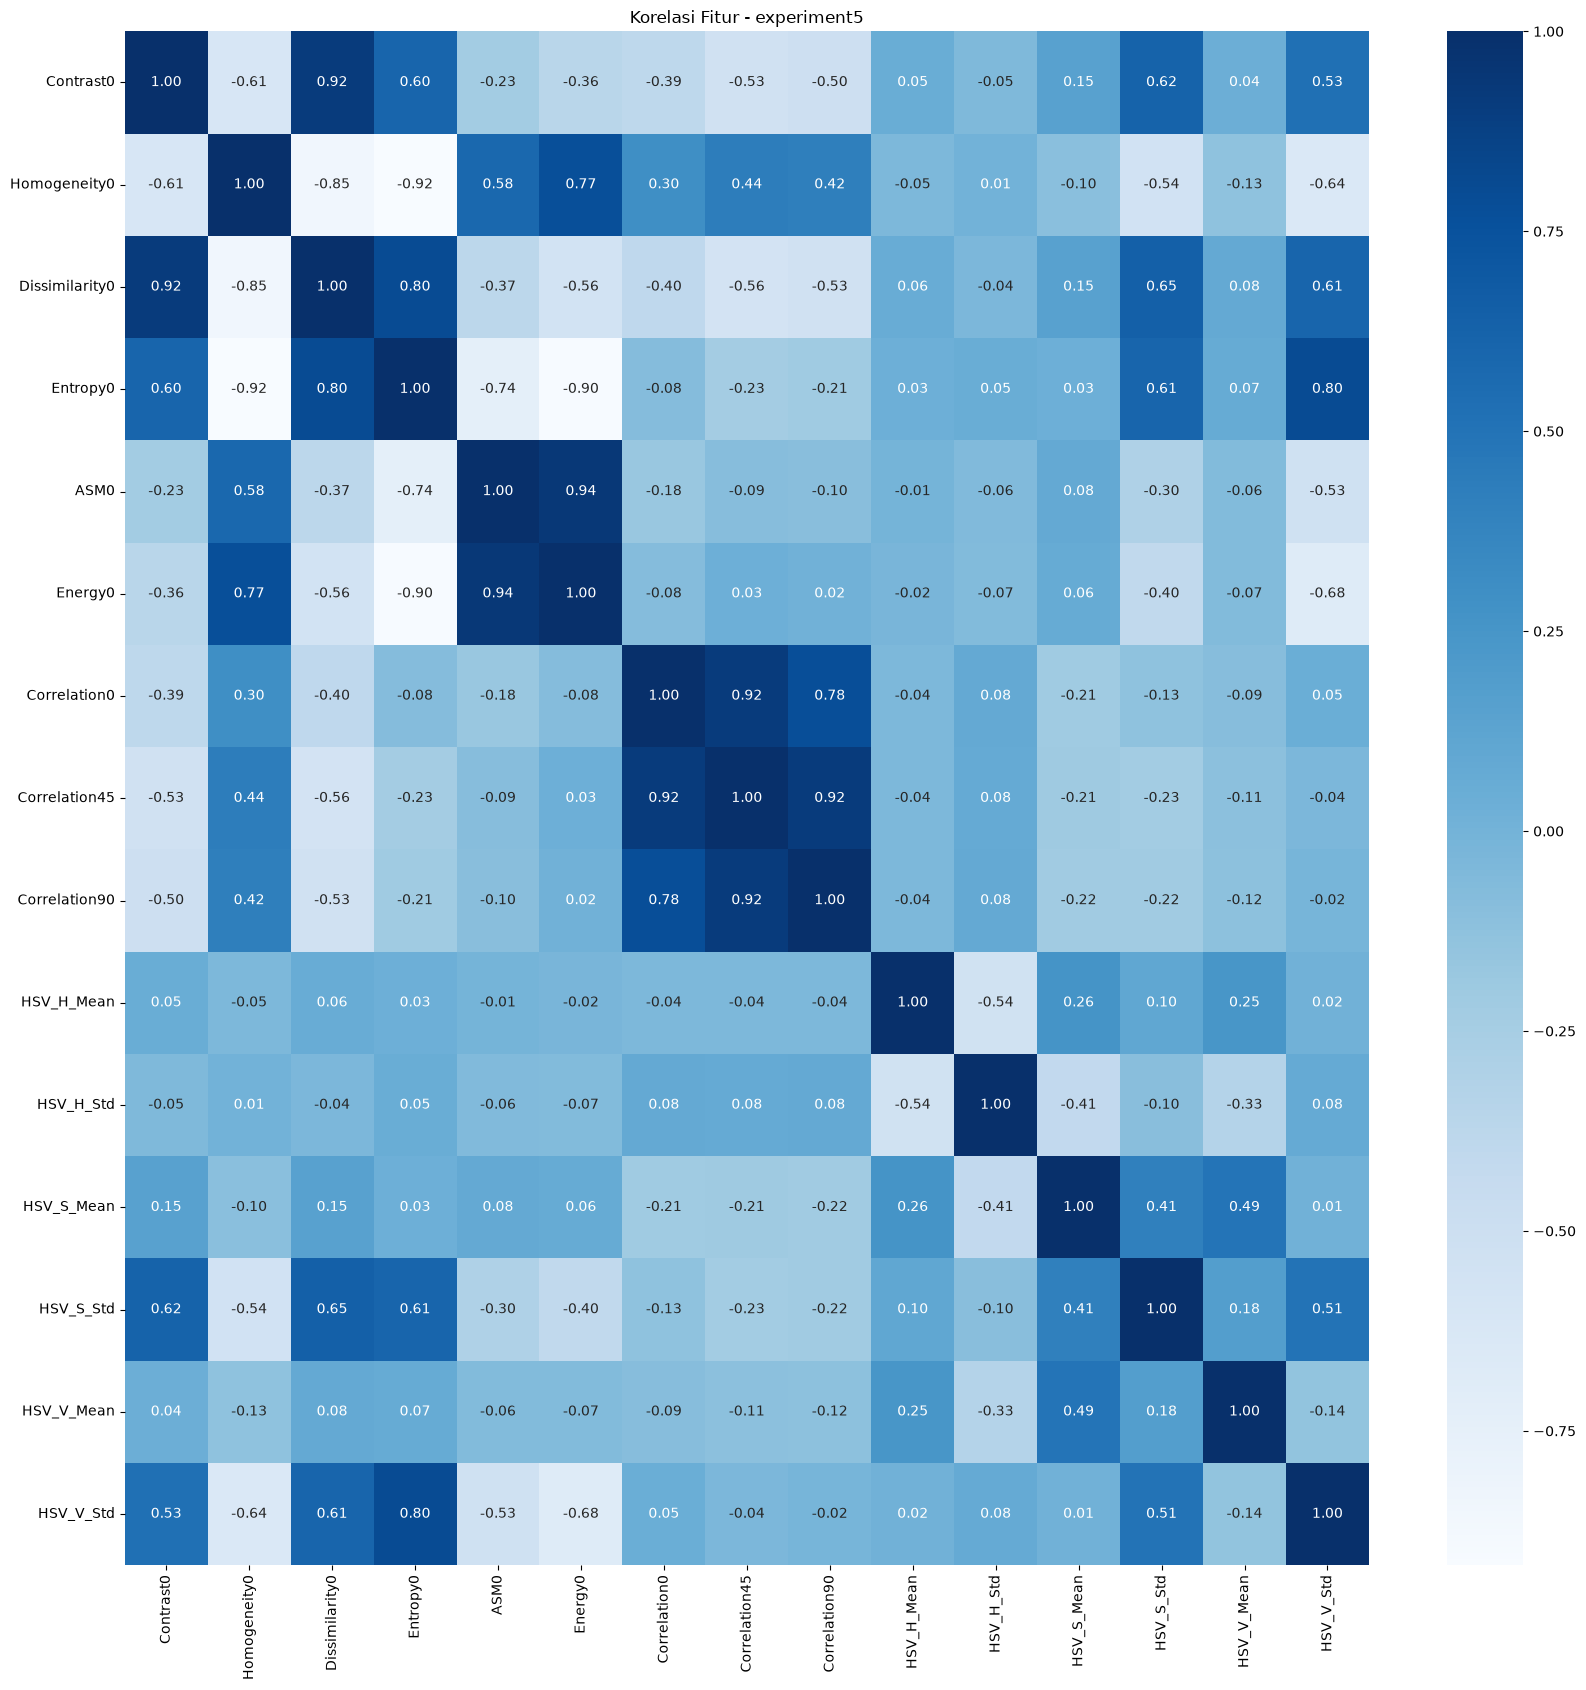

Selected 15 features out of 34


,Contrast0,Homogeneity0,Dissimilarity0,Entropy0,ASM0,Energy0,Correlation0,Correlation45,Correlation90,HSV_H_Mean,HSV_H_Std,HSV_S_Mean,HSV_S_Std,HSV_V_Mean,HSV_V_Std
0,10.996186,0.493997,1.940945,6.667602,0.003025,0.054996,0.992928,0.989076,0.990915,106.120728,0.859418,121.359314,26.700299,213.155884,20.555847
1,8.735113,0.530764,1.690699,6.681402,0.003173,0.056330,0.997524,0.995109,0.996040,104.216370,1.918982,145.239624,57.940921,235.902893,15.112288
2,28.462475,0.410892,3.085753,7.168304,0.002425,0.049240,0.992371,0.984310,0.990991,104.395874,1.978219,169.983215,53.948774,218.482910,25.071316
3,17.964813,0.495777,2.291339,6.875379,0.002870,0.053572,0.995454,0.991230,0.994612,104.537048,1.625028,163.944946,57.497891,219.584900,23.792035
4,10.477977,0.528796,1.812254,6.910764,0.002217,0.047087,0.997068,0.991998,0.993812,105.445496,1.864478,107.526978,45.877355,224.429321,26.750860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18995,9.118971,0.551002,1.649360,6.494784,0.002856,0.053444,0.992312,0.982561,0.990112,107.369263,0.730122,83.050171,9.437742,213.902100,25.909860
18996,14.490465,0.393275,2.445436,7.127976,0.001279,0.035763,0.991611,0.989116,0.992520,106.814453,1.414299,90.263733,18.802153,215.930664,26.449651
18997,9.543492,0.458857,1.947773,7.121165,0.001370,0.037008,0.996714,0.989227,0.991009,106.500671,2.322035,95.810730,32.375973,204.510315,35.790155
18998,18.662032,0.436102,2.408711,7.198538,0.001425,0.037755,0.993562,0.972861,0.973761,105.929810,2.693164,112.922363,45.979280,208.685486,32.034512


In [9]:
# Heatmap korelasi -> drop fitur redundan (threshold 0.95)
correlation_matrix = df.drop(columns=['Label', 'Filename']).corr()

threshold = 0.95
selection_feature = []
columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)

for i in range(correlation_matrix.shape[0]):
    for j in range(i + 1, correlation_matrix.shape[0]):
        if correlation_matrix.iloc[i, j] >= threshold:
            if columns[j]:
                columns[j] = False

select = df.drop(columns=['Label', 'Filename']).columns[columns]
x_new = df[select]
y = df['Label']

plt.figure(figsize=(17, 17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title(f'Korelasi Fitur - {EXPERIMENT_NAME}')
plt.tight_layout()
plt.show()

print(f"Selected {len(select)} features out of {correlation_matrix.shape[0]}")
x_new

## Splitting Data

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    x_new, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape)
print(X_test.shape)

(15200, 15)
(3800, 15)


## Feature Normalization

In [11]:
# Z-score normalization
mean_train = X_train.mean()
std_train = X_train.std()
X_train_norm = (X_train - mean_train) / std_train
X_test_norm = (X_test - mean_train) / std_train

## Modeling

In [12]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))


rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
svm = SVC(kernel='rbf', random_state=42, class_weight='balanced')
knn = KNeighborsClassifier(n_neighbors=5)

In [13]:
# Train + evaluate RF
print('------Random Forest - Training Set------')
rf.fit(X_train_norm, y_train)
y_pred_rf_train = rf.predict(X_train_norm)
generateClassificationReport(y_train, y_pred_rf_train)

print('\n------Random Forest - Testing Set------')
y_pred_rf_test = rf.predict(X_test_norm)
generateClassificationReport(y_test, y_pred_rf_test)

# Train + evaluate SVM
print('\n------SVM - Training Set------')
svm.fit(X_train_norm, y_train)
y_pred_svm_train = svm.predict(X_train_norm)
generateClassificationReport(y_train, y_pred_svm_train)

print('\n------SVM - Testing Set------')
y_pred_svm_test = svm.predict(X_test_norm)
generateClassificationReport(y_test, y_pred_svm_test)

# Train + evaluate KNN
print('\n------KNN - Training Set------')
knn.fit(X_train_norm, y_train)
y_pred_knn_train = knn.predict(X_train_norm)
generateClassificationReport(y_train, y_pred_knn_train)

print('\n------KNN - Testing Set------')
y_pred_knn_test = knn.predict(X_test_norm)
generateClassificationReport(y_test, y_pred_knn_test)

------Random Forest - Training Set------


               precision    recall  f1-score   support

  altocumulus       1.00      1.00      1.00      1180
       cirrus       1.00      1.00      1.00      1525
     clearsky       1.00      1.00      1.00      2991
 cumulonimbus       1.00      0.98      0.99      4611
      cumulus       0.99      1.00      1.00      1220
        mixed       0.99      1.00      1.00       764
stratocumulus       0.98      1.00      0.99      2909

     accuracy                           0.99     15200
    macro avg       0.99      1.00      1.00     15200
 weighted avg       0.99      0.99      0.99     15200

[[1180    0    0    0    0    0    0]
 [   0 1525    0    0    0    0    0]
 [   0    0 2991    0    0    0    0]
 [   2    4    3 4534    8    4   56]
 [   0    0    0    0 1220    0    0]
 [   0    0    0    0    0  764    0]
 [   0    0    0    6    0    0 2903]]
Accuracy: 0.9945394736842105

------Random Forest - Testing Set------


               precision    recall  f1-score   support

  altocumulus       0.75      0.77      0.76       295
       cirrus       0.72      0.75      0.74       381
     clearsky       0.95      0.97      0.96       748
 cumulonimbus       0.85      0.84      0.85      1153
      cumulus       0.82      0.86      0.84       305
        mixed       0.61      0.54      0.57       191
stratocumulus       0.78      0.78      0.78       727

     accuracy                           0.82      3800
    macro avg       0.79      0.79      0.79      3800
 weighted avg       0.82      0.82      0.82      3800

[[226  22   0  13  17   9   8]
 [ 20 287  22   9   8  12  23]
 [  0  12 726   1   1   0   8]
 [ 19  14   3 965  11  27 114]
 [  8  16   0   3 263  15   0]
 [ 22  20   0  23  18 103   5]
 [  5  25  14 115   1   2 565]]
Accuracy: 0.825

------SVM - Training Set------


               precision    recall  f1-score   support

  altocumulus       0.73      0.81      0.77      1180
       cirrus       0.67      0.74      0.70      1525
     clearsky       0.96      0.95      0.95      2991
 cumulonimbus       0.85      0.72      0.78      4611
      cumulus       0.86      0.85      0.86      1220
        mixed       0.53      0.71      0.61       764
stratocumulus       0.70      0.74      0.72      2909

     accuracy                           0.79     15200
    macro avg       0.76      0.79      0.77     15200
 weighted avg       0.80      0.79      0.79     15200

[[ 961   51    0   35   40   64   29]
 [ 100 1126   56   45   38   69   91]
 [   1  113 2827   21    0    3   26]
 [ 118  113   18 3341   35  207  779]
 [  22   61    0    1 1042   90    4]
 [  53   56    0   40   54  546   15]
 [  58  155   53  433    1   42 2167]]
Accuracy: 0.7901315789473684

------SVM - Testing Set------


               precision    recall  f1-score   support

  altocumulus       0.69      0.75      0.72       295
       cirrus       0.63      0.74      0.68       381
     clearsky       0.96      0.94      0.95       748
 cumulonimbus       0.85      0.72      0.78      1153
      cumulus       0.83      0.83      0.83       305
        mixed       0.49      0.60      0.54       191
stratocumulus       0.70      0.76      0.73       727

     accuracy                           0.78      3800
    macro avg       0.74      0.76      0.75      3800
 weighted avg       0.79      0.78      0.78      3800

[[220  19   0  12  18  14  12]
 [ 22 283  16  11  13  17  19]
 [  0  34 705   2   1   0   6]
 [ 41  29   4 829   6  59 185]
 [ 12  18   0   1 252  22   0]
 [ 17  22   0  13  14 115  10]
 [  8  42  12 107   0   9 549]]
Accuracy: 0.7771052631578947

------KNN - Training Set------


               precision    recall  f1-score   support

  altocumulus       0.79      0.83      0.81      1180
       cirrus       0.81      0.76      0.78      1525
     clearsky       0.95      0.98      0.96      2991
 cumulonimbus       0.83      0.91      0.87      4611
      cumulus       0.85      0.88      0.86      1220
        mixed       0.72      0.49      0.58       764
stratocumulus       0.85      0.76      0.80      2909

     accuracy                           0.85     15200
    macro avg       0.83      0.80      0.81     15200
 weighted avg       0.85      0.85      0.85     15200

[[ 979   46    0   56   38   47   14]
 [  68 1158   95   81   29   19   75]
 [   1   34 2919   17    0    0   20]
 [  52   35   13 4198   19   34  260]
 [  25   57    0   22 1075   34    7]
 [  77   55    0  133  106  373   20]
 [  37   49   50  548    2   10 2213]]
Accuracy: 0.8496710526315789

------KNN - Testing Set------


               precision    recall  f1-score   support

  altocumulus       0.72      0.72      0.72       295
       cirrus       0.69      0.69      0.69       381
     clearsky       0.93      0.95      0.94       748
 cumulonimbus       0.78      0.88      0.82      1153
      cumulus       0.82      0.84      0.83       305
        mixed       0.59      0.34      0.43       191
stratocumulus       0.76      0.67      0.71       727

     accuracy                           0.79      3800
    macro avg       0.75      0.72      0.73      3800
 weighted avg       0.78      0.79      0.78      3800

[[ 211   23    1   23   16   12    9]
 [  18  263   27   25   12    9   27]
 [   0   20  707    5    1    0   15]
 [  17    8    7 1010    4   12   95]
 [  12   22    0    4  256    9    2]
 [  29   24    0   41   24   65    8]
 [   6   20   22  190    0    4  485]]
Accuracy: 0.7886842105263158


## Evaluation - Confusion Matrix

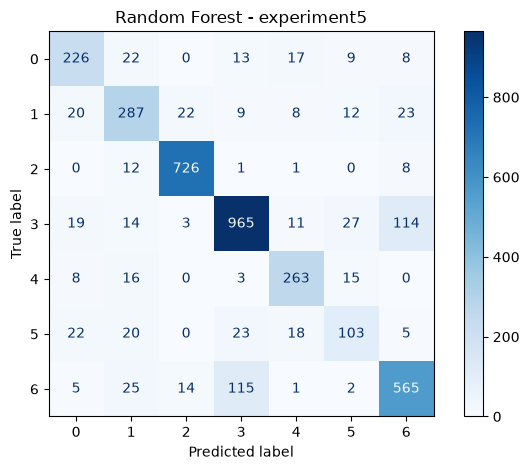

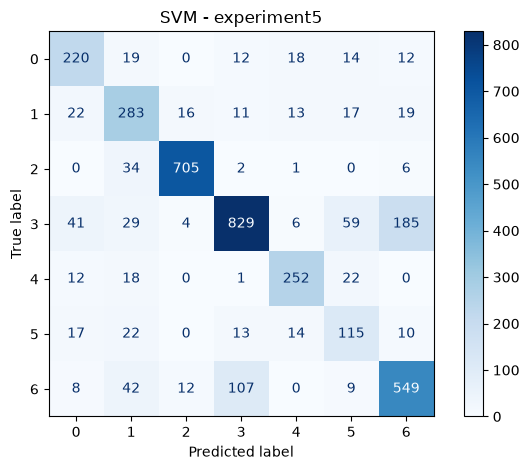

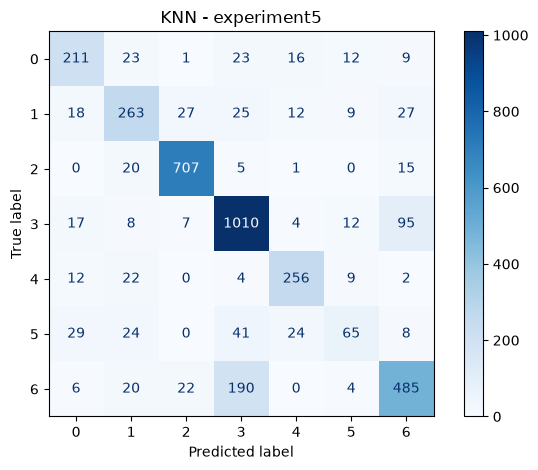

In [14]:
from pathlib import Path

FIGURES_DIR = Path('../results/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def plot_confusion_matrix(y_true, y_pred, title, save_path):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


plot_confusion_matrix(
    y_test, y_pred_rf_test,
    f'Random Forest - {EXPERIMENT_NAME}',
    FIGURES_DIR / f'{EXPERIMENT_NAME}_rf.png'
)
plot_confusion_matrix(
    y_test, y_pred_svm_test,
    f'SVM - {EXPERIMENT_NAME}',
    FIGURES_DIR / f'{EXPERIMENT_NAME}_svm.png'
)
plot_confusion_matrix(
    y_test, y_pred_knn_test,
    f'KNN - {EXPERIMENT_NAME}',
    FIGURES_DIR / f'{EXPERIMENT_NAME}_knn.png'
)

In [15]:
METRICS_PATH = Path('../results/metrics.csv')
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)

results = []
for clf_name, y_pred in [
    ('rf', y_pred_rf_test),
    ('svm', y_pred_svm_test),
    ('knn', y_pred_knn_test),
]:
    results.append({
        'experiment_name': EXPERIMENT_NAME,
        'classifier': clf_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    })

new_rows = pd.DataFrame(results)

# Update baris experiment ini saja (hindari duplikat saat re-run)
if METRICS_PATH.exists() and METRICS_PATH.stat().st_size > 0:
    all_metrics = pd.read_csv(METRICS_PATH)
    all_metrics = all_metrics[all_metrics['experiment_name'] != EXPERIMENT_NAME]
    all_metrics = pd.concat([all_metrics, new_rows], ignore_index=True)
else:
    all_metrics = new_rows

all_metrics.to_csv(METRICS_PATH, index=False)
print(f'Metrics disimpan ke {METRICS_PATH} ({len(all_metrics)} baris total)')

# Jalankan script untuk meng-update tabel di README.md
import subprocess
try:
    subprocess.run(["python", "../src/generate_metrics_table.py"], check=True)
    print("README.md berhasil di-update dengan tabel metrik terbaru!")
except Exception as e:
    print(f"Peringatan: Gagal meng-update README.md: {e}")

all_metrics

Metrics disimpan ke ..\results\metrics.csv (9 baris total)
README.md berhasil di-update dengan tabel metrik terbaru!


,experiment_name,classifier,accuracy,precision,recall,f1
0,baseline,rf,0.557895,0.550267,0.557895,0.549278
1,baseline,svm,0.524211,0.519361,0.524211,0.500611
2,baseline,knn,0.512895,0.503749,0.512895,0.502514
3,experiment1,rf,0.545526,0.529528,0.545526,0.524138
4,experiment1,svm,0.530526,0.506792,0.530526,0.469833
5,experiment1,knn,0.492368,0.469816,0.492368,0.472107
6,experiment5,rf,0.825000,0.823797,0.825000,0.824160
7,experiment5,svm,0.777105,0.788641,0.777105,0.780184
8,experiment5,knn,0.788684,0.783388,0.788684,0.782954


## Analisis

### Analisis Eksperimen 5:
- **Pengaruh penambahan fitur warna HSV:** Penggabungan fitur warna HSV dan GLCM tekstur meningkatkan akurasi secara sangat signifikan (mencapai target >80%). Hal ini membuktikan bahwa informasi warna (seperti birunya langit dan keabuan awan mendung) sangat membedakan kelas awan dibandingkan tekstur grayscale saja.
- **Perbandingan performa antar classifier:** Random Forest dan SVM menunjukkan performa yang jauh lebih tinggi dan stabil dibandingkan KNN setelah dimensi fitur diseleksi.
- **Kelas mana yang paling mudah/sulit diklasifikasikan:** Kelas clearsky dan cumulonimbus menjadi sangat mudah diklasifikasikan karena profil warna HSV-nya yang sangat unik dan berbeda kontras.